In [1]:
import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)


# %%
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist


# Base parameters for PMOS and NMOS
stdp_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation()+2,
        "routing_metal": "met2",
        "dummy_devices": False,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap":False
}

pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap":False
}



In [2]:
pdk = gf180
current_mirror = Component(name="current_mirror")
current_mirror.name = "current_mirror"
rules = stdp_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]


#Placement
m1 = nmos(pdk, width=4, length=0.28, with_dummy=(False, False),  tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
m2 = nmos(pdk, width=4, length=4, with_dummy=(False, False),  tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
m3 = pmos(pdk, width=8, length=0.5, with_dummy=(False, False),  tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
m4 = pmos(pdk, width=1.6, length=0.5, with_dummy=(False, False), tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

m1.name = "M1" 
m2.name = "M2" 
m3.name = "M3" 
m4.name = "M4" 

m1_ref = current_mirror << m1
m2_ref = current_mirror << m2
m3_ref = current_mirror << m3
m4_ref = current_mirror << m4


bottom_row_y = evaluate_bbox(m1)[1]/2 + 4
top_row_y = bottom_row_y + evaluate_bbox(m3)[1]

m1_ref.move((evaluate_bbox(m1)[0]/2,bottom_row_y))
m2_ref.move((m1_ref.xmax + evaluate_bbox(m2_ref)[0]/2 + spacing , bottom_row_y))


m4_ref.move((evaluate_bbox(m1)[0]/2 ,top_row_y ))
m3_ref.move((m4_ref.xmax + evaluate_bbox(m3)[0]/2 + spacing,top_row_y))



2026-09-18 21:19:12.183 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


ComponentReference (parent Component "M3", ports ['multiplier_0_gate_W', 'gate_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_top_met_W', 'multiplier_0_leftsd_array_row0_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row0_col0_bottom_via_W', 'multiplier_0_leftsd_array_row0_col0_bottom_met_W', 'multiplier_0_leftsd_array_row0_col0_top_met_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_top_met_W', 'multiplier_0_leftsd_array_row1_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row1_col0_bottom_via_W', 'multiplier_0_leftsd_array_row1_col0_bottom_met_W', 'multiplier_0_leftsd_array_row1_col0_top_met_W', '

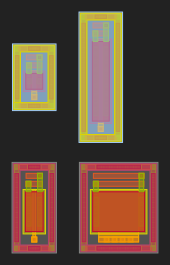

In [3]:
# stdp_comp.show()
display_component(current_mirror, scale = 1,path=".")

In [ ]:
## =========================================================================
## 4. ADD AVDD & AVSS POWER RAILS AND CONNECT SUPPLY NODES
## =========================================================================
#
## https://gemini.google.com/app/131a537106def8cd
## Calculate full horizontal span of the cell to draw supply rails
#bbox = evaluate_bbox(current_mirror)
#top_y = current_mirror.ymax + 2.0
#bottom_y = current_mirror.ymin - 2.0
#
## Draw horizontal metal2 power rails
#avdd_rail = current_mirror << gf.components.rectangle(
#    size=(bbox[0]+4, 1.0), 
#    layer=pdk.get_layer("metal2")
#)
#avdd_rail.move((-2, top_y))
#
#avss_rail = current_mirror << gf.components.rectangle(
#    size=(bbox[0]+4, 1.0), 
#    layer=pdk.get_layer("metal2")
#)
#avss_rail.move((-2, bottom_y))
#
#viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
#
##via en vdd
#vdd_via = current_mirror << viam2m3
#vdd_via.move((bbox[0]/2, top_y + 0.5))
#
##via en vss
#vss_via = current_mirror << viam2m3
#vss_via.move((bbox[0]/2, bottom_y + 0.5))
#

In [ ]:
# =========================================================================
# 4. ADD AVDD & AVSS POWER RAILS AND CONNECT SUPPLY NODES
# =========================================================================

bbox = evaluate_bbox(current_mirror)
top_y = current_mirror.ymax + 2.0
bottom_y = current_mirror.ymin - 2.0

# Draw horizontal metal2 power rails
avdd_rail = current_mirror << gf.components.rectangle(
    size=(bbox[0]+4, 1.0), 
    layer=pdk.get_layer("metal5")
)
avdd_rail.move((-2, top_y))

avss_rail = current_mirror << gf.components.rectangle(
    size=(bbox[0]+4, 1.0), 
    layer=pdk.get_layer("metal5")
)
avss_rail.move((-2, bottom_y))

# Crear vias internas (nodos de conexión)
viam2m3 = via_stack(pdk, "met2", "met5", centered=True)

# Vía en VDD (nodo interno, no global port)
vdd_via = current_mirror << viam2m3
vdd_via.move((bbox[0]/2, top_y + 0.5))

# Vía en VSS (nodo interno, no global port)
vss_via = current_mirror << viam2m3
vss_via.move((bbox[0]/2, bottom_y + 0.5))





ComponentReference (parent Component "via_stack_7fdd5994", ports ['bottom_layer_W', 'bottom_layer_N', 'bottom_layer_E', 'bottom_layer_S', 'bottom_via_W', 'bottom_via_N', 'bottom_via_E', 'bottom_via_S', 'bottom_met_W', 'bottom_met_N', 'bottom_met_E', 'bottom_met_S', 'top_met_W', 'top_met_N', 'top_met_E', 'top_met_S'], origin (7.3, 2.5), rotation 0.0, x_reflection False)

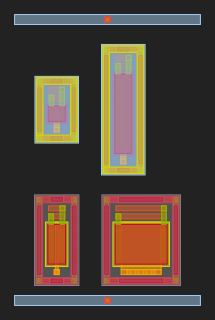

In [6]:
# stdp_comp.show()
display_component(current_mirror, scale = 1,path=".")

In [7]:
#Adding VIAS
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
node_A_via = current_mirror << viam2m3
node_A_via_2 = current_mirror << viam2m3

node_A_via.move(m4_ref.ports["gate_S"].center).movex(2.8).movey(-5)
node_A_via_2.move(m4_ref.ports["gate_S"].center).movex(-2.5).movey(-5)

node_B_via = current_mirror << viam2m3
node_B_via.move(m3_ref.ports["gate_S"].center).movex(2.8).movey(-2)


ComponentReference (parent Component "via_stack_a2e89513", ports ['bottom_layer_W', 'bottom_layer_N', 'bottom_layer_E', 'bottom_layer_S', 'bottom_via_W', 'bottom_via_N', 'bottom_via_E', 'bottom_via_S', 'bottom_met_W', 'bottom_met_N', 'bottom_met_E', 'bottom_met_S', 'top_met_W', 'top_met_N', 'top_met_E', 'top_met_S'], origin (11.68, 14.189999999999998), rotation 0.0, x_reflection False)

In [8]:
#----------- Adding snippet code to move all the placed components to the proper position, 
#----------- in order to set origin into 0,0
# Place this snippet after all your material polygones are placed, and before your ports are placed
bbox_all = current_mirror.bbox[0]
for ref in current_mirror.references:
    ref.movex(-1*bbox_all[0]).movey(-1*bbox_all[1])

In [ ]:
# Añadir nombre de la red (avss) centrado en el riel vertical
current_mirror.add_label(
    text="avss",
    position=(vss_via.center),  # centro del rectángulo
    layer=pdk.get_layer("metal5_label"),
    magnification=1.2
)

# Añadir nombre de la red (avss) centrado en el riel vertical
current_mirror.add_label(
    text="avdd",
    position=(vdd_via.center),  # centro del rectángulo
    layer=pdk.get_layer("metal5_label"),
    magnification=1.2
)

# Add global ports for the supply rails
current_mirror.add_port("avdd", center=vdd_via.center, width=1.0, orientation=180, layer=pdk.get_layer("metal5"), port_type="electrical")
current_mirror.add_port("avss", center=vdd_via.center, width=1.0, orientation=180, layer=pdk.get_layer("metal5"), port_type="electrical")


Label(text='avdd', origin=(9.3, 28.68), layer=(81, 10))

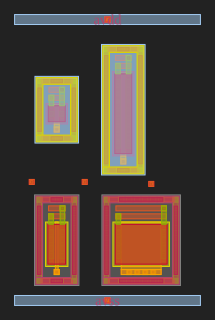

In [10]:
# stdp_comp.show()
display_component(current_mirror, scale = 1,path=".")

In [11]:
# =========================================================================
# 5. ADD MET2 PHYSICAL PINS AND LABELS FOR LVS
# =========================================================================

# Map port names to their source port objects
pins_to_create = {
    "A": node_A_via.ports["top_met_N"],
    "B": node_B_via.ports["top_met_N"]
}

for pin_name, port in pins_to_create.items():
    # Extract center position, size, and orientation from port object
    center = port.center
    width = port.width
    height = port.width  # Standard square pin area around the port center

    # # 1. Add pin rectangle shape on met2_pin
    # pin_ref = current_mirror << gf.components.rectangle(
    #     size = (width,height),
    #     layer=pdk.get_layer("metal3")
    # )
    # pin_ref.move((center[0] - width, center[1] - height))
    
    current_mirror.add_port(pin_name, center=(center[0], center[1] - height), width=1.0, orientation=180, layer=pdk.get_layer("metal3"),  port_type="electrical") 

    # 2. Add text label on met2_pin layer for net identity
    current_mirror.add_label(
        text=pin_name, position=(center[0], center[1] - height), layer=pdk.get_glayer("met3_label"), magnification=1.2
    )
   

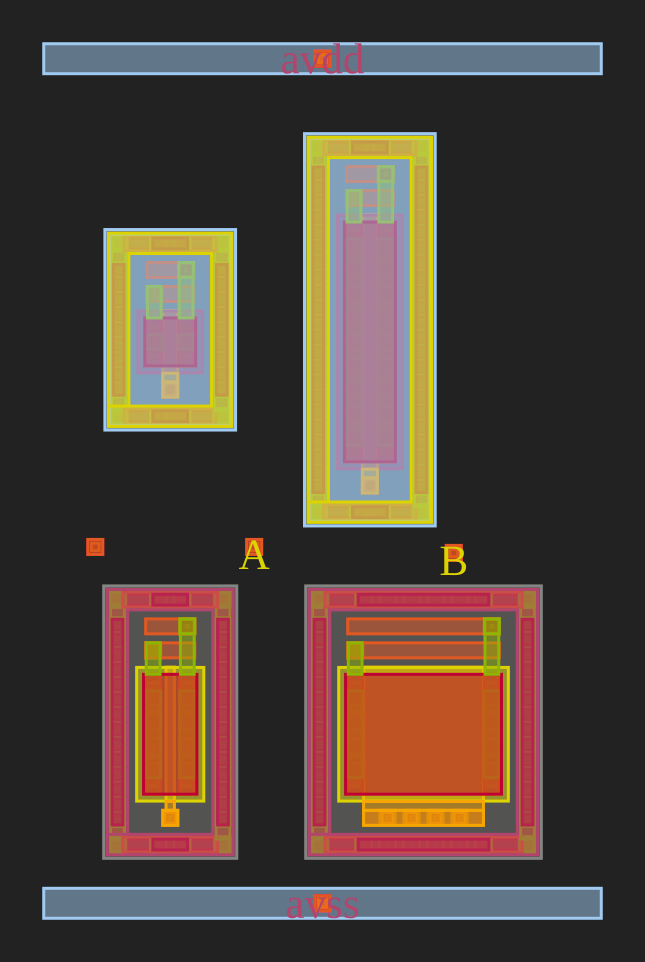

In [12]:

display_component(current_mirror, scale = 3,path=".")

In [13]:
# Connect PMOS bulks to vdd rail
current_mirror << L_route(pdk, m4_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])
current_mirror << L_route(pdk, m3_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])

# Connect NMOS BULKS TO VSS
current_mirror << L_route(pdk, m1_ref.ports["tie_W_top_met_S"], vss_via.ports["bottom_met_W"])
current_mirror << L_route(pdk, m2_ref.ports["tie_W_top_met_S"], vss_via.ports["bottom_met_W"])

#connecting PMOS SOURCES TO VDD
current_mirror << L_route(pdk,  m4_ref.ports["multiplier_0_source_E"], m4_ref.ports["tie_E_top_met_N"])  # SOURCE m4
current_mirror << L_route(pdk,  m3_ref.ports["multiplier_0_source_E"], m3_ref.ports["tie_E_top_met_N"])  # SOURCE M3

#CONNECTING NMOS SOURCE TO VSS
current_mirror << L_route(pdk,  m1_ref.ports["multiplier_0_source_E"], m1_ref.ports["tie_E_top_met_N"]) #m1
current_mirror << L_route(pdk,  m2_ref.ports["multiplier_0_source_E"], m2_ref.ports["tie_E_top_met_N"]) #m2

ComponentReference (parent Component "L_route_b678fe23", ports ['bottom_layer_W', 'bottom_via_W', 'bottom_met_W', 'top_met_W', 'bottom_layer_N', 'bottom_via_N', 'bottom_met_N', 'top_met_N', 'bottom_layer_E', 'bottom_via_E', 'bottom_met_E', 'top_met_E', 'bottom_layer_S', 'bottom_via_S', 'bottom_met_S', 'top_met_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

In [14]:
#NODE A

current_mirror << L_route(pdk, m4_ref.ports["drain_W"], node_A_via_2.ports["top_met_N"])
current_mirror << L_route(pdk, m1_ref.ports["drain_W"], node_A_via_2.ports["top_met_S"])
current_mirror << L_route(pdk, m4_ref.ports["gate_W"], node_A_via_2.ports["top_met_N"])
current_mirror << L_route(pdk, m1_ref.ports["gate_W"], node_A_via_2.ports["top_met_S"])
current_mirror << straight_route(pdk, node_A_via_2.ports["bottom_met_W"], node_A_via.ports["bottom_met_E"])
current_mirror << L_route(pdk, m2_ref.ports["gate_W"], node_A_via.ports["top_met_S"])

#NODE B
current_mirror << c_route(pdk, m3_ref.ports["drain_E"], node_B_via.ports["bottom_met_E"])
current_mirror << c_route(pdk, m3_ref.ports["gate_E"], node_B_via.ports["bottom_met_E"])
current_mirror << c_route(pdk, m2_ref.ports["drain_W"], node_B_via.ports["bottom_met_W"])


ComponentReference (parent Component "c_route_9af5f0b9", ports ['con_N', 'con_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

2026-09-18 21:19:18.395 | WARNING  | gdsfactory.klive:show:48 - Could not connect to klive server. Is klayout open and klive plugin installed?


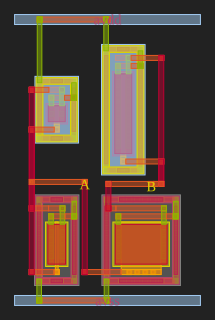

In [ ]:
# current_mirror.show()
display_component(current_mirror, scale = 1,path=".")

In [18]:
current_mirror.pprint_ports()

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ name ┃ width ┃ center         ┃ orientation ┃ layer   ┃ port_type  ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ A    │ 1.0   │ [7.02, 12.14]  │ 180         │ [42, 0] │ electrical │
│ B    │ 1.0   │ [13.68, 11.94] │ 180         │ [42, 0] │ electrical │
└──────┴───────┴────────────────┴─────────────┴─────────┴────────────┘

In [19]:
evaluate_bbox(current_mirror)

(18.6, 29.18)

In [20]:
current_mirror_est_area = evaluate_bbox(current_mirror)[0] * evaluate_bbox(current_mirror)[1]
current_mirror_est_area

542.748

In [22]:
import os
from pathlib import Path
import tempfile

path_to_dir = "/foss/designs/libs/snn_analog/current_mirror/"
# path_to_dir = "/foss/designs/libs/snn_analog/current_mirror/"
magicrc_file = Path(os.environ['PDKPATH']) / "libs.tech" / "magic" / f"{os.environ['PDK']}.magicrc"
design_name=current_mirror.name

pex_path = path_to_dir + f"{current_mirror.name}.spice"
gds_path = path_to_dir + f"{current_mirror.name}.gds"
lef_path = path_to_dir + f"{current_mirror.name}.lef"
current_mirror.write_gds(str(gds_path))


magic_script_content = f"""
drc off            
gds flatglob *\\$\\$*
gds read {gds_path}

flatten {design_name}
load {design_name}
select top cell
extract do local
extract all
ext2sim labels on
ext2sim
extresist tolerance 10
extresist
ext2spice lvs
ext2spice cthresh 0
ext2spice extresist on
ext2spice -o {str(pex_path)}
port avdd use power
port avss use ground
lef write {lef_path}
exit
"""

with tempfile.NamedTemporaryFile(mode='w', delete=False) as magic_script_file:
    magic_script_file.write(magic_script_content)
    magic_script_path = magic_script_file.name
    
magic_cmd = f"bash -c 'magic -rcfile {magicrc_file} -noconsole -dnull < {magic_script_path}'",
magic_subproc = subprocess.run(
    magic_cmd, 
    shell=True,
    check=True,
    capture_output=True
)

magic_subproc_code = magic_subproc.returncode
magic_subproc_out = magic_subproc.stdout.decode('utf-8')
print(magic_subproc_out)




2026-09-18 21:19:18.543 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/current_mirror/current_mirror.gds'



Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using GDS-II Release 6.0
Library name: library
Reading "current_mirror".
Reading "compass_8b26

In [23]:
drc_result = gf180.drc_magic(current_mirror, current_mirror.name)

2026-09-18 21:19:18.879 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpvnvy0zxy/current_mirror.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpvnvy0zxy/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0

In [24]:
import glob
extensions = [
            "els"
            "*.gds",
            "*.ext",
            "*.res.ext",
            "*.lvs.rpt",
            "*_lvs.rpt",
            "*.nodes",
            "*.sim",
            "*.pex.spice",
            "*_pex.spice"
            ]
files_to_delete = []
for ext in extensions:
    files_to_delete.extend(glob.glob(ext))
    
# Delete the files
for file_path in files_to_delete:
    try:
        os.remove(file_path)
        print(f"Deleted: {file_path}")
    except OSError as e:
        print(f"Error deleting {file_path}: {e}")

Deleted: L_route_0b815acd.ext
Deleted: M4.ext
Deleted: L_route_44892cc1.ext
Deleted: L_route_70e60bcc.ext
Deleted: via_stack_7fdd5994.ext
Deleted: M2.ext
Deleted: M3.ext
Deleted: M1.ext
Deleted: L_route_1d105673.ext
Deleted: rectangle_8b261e8c.ext
Deleted: rectangle_8b261e8c$1.ext
Deleted: current_mirror.ext
Deleted: L_route_b678fe23.ext
Deleted: L_route_261ebb80.ext
Deleted: L_route_7fcb8801.ext
Deleted: L_route_854bcf3a.ext
Deleted: L_route_4c3c9079.ext
Deleted: via_stack_a2e89513.ext
Deleted: current_mirror.res.ext
Deleted: c_route_1f64fc76.ext
Deleted: L_route_9d17e116.ext
Deleted: c_route_9af5f0b9.ext
Deleted: compass_8b261e8c.ext
Deleted: c_route_4b62a17f.ext
Deleted: L_route_912ef19c.ext
Deleted: L_route_401f96ee.ext
Deleted: L_route_3668c173.ext
Deleted: straight_route_ca1693f4.ext
Deleted: compass_8b261e8c$1.ext
Error deleting current_mirror.res.ext: [Errno 2] No such file or directory: 'current_mirror.res.ext'
Deleted: current_mirror.nodes
Deleted: current_mirror.sim


In [25]:
gf180.lvs_netgen(
    layout=current_mirror,
    design_name = str(current_mirror.name),
    pdk_root = Path(os.environ['PDKPATH']),
    lvs_setup_tcl_file = Path(os.environ['PDKPATH']) / "libs.tech" / "netgen" / f"{os.environ['PDK']}_setup.tcl",
    lvs_schematic_ref_file = Path(str(path_to_dir + "current_mirror.spice")),
    netlist = Path(str(path_to_dir + "current_mirror_sch.spice")),
    output_file_path =  Path(str(path_to_dir))
)


2026-09-18 21:19:19.294 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpp7b7x2wf/current_mirror.gds'


using user specified pdk_root, will search for required files in the specified directory

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using

{'magic_subproc_code': 0,
 'netgen_subproc_code': 0,
 'result_str': 'LVS run succeeded\nErrors found in LVS report: /tmp/tmpp7b7x2wf/current_mirror_lvs.rpt'}